### 1. 数据准备与基础模型构建 ###

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq, minimize_scalar
from scipy.integrate import quad
from scipy.ndimage import gaussian_filter1d

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False  

# === 1. 基础物理模型 (标准大气) ===
def get_atmosphere(altitude_ft):
    rho_sl = 0.0023769    # 海平面空气密度 (slug/ft³)
    T_sl = 518.67         # 海平面温度 (°R，兰金温标)
    a_sl_kts = 661.47     # 海平面声速 (节，kts)
    
    if altitude_ft <= 36089:  # 对流层（≤11km，约36089英尺）
        T = T_sl - 0.003566 * altitude_ft  # 对流层温度随高度线性降低
        theta = T / T_sl                   # 温度比（当地温度/海平面温度）
        sigma = theta ** 4.2561            # 密度比（当地密度/海平面密度，对流层公式）
    else:  # 平流层（>36089英尺）
        T_trop = T_sl - 0.003566 * 36089   # 对流层顶温度
        theta_trop = T_trop / T_sl         # 对流层顶温度比
        h_diff = altitude_ft - 36089       # 超出对流层顶的高度
        sigma = (theta_trop ** 4.2561) * np.exp(-h_diff / 20806)  # 平流层密度比（指数衰减）
        theta = theta_trop  # 平流层温度恒定
    
    rho = rho_sl * sigma    # 当地空气密度
    a_kts = a_sl_kts * np.sqrt(theta)  # 当地声速（声速与温度平方根成正比）
    return rho, a_kts

# === 2. 统一发动机数据模型 ===
class AeroEngine:
    def __init__(self, name, thrust_matrix, sfc_matrix, alts_grid, machs_grid):
        self.name = name
        # 建立二维插值器：输入(高度,马赫数)，输出推力/SFC
        self.thrust_interp = RegularGridInterpolator((alts_grid, machs_grid), thrust_matrix, bounds_error=False, fill_value=None)
        self.sfc_interp = RegularGridInterpolator((alts_grid, machs_grid), sfc_matrix, bounds_error=False, fill_value=None)

    def get_thrust(self, h, m):
        h = np.clip(h, 0, 50000) # 限制高度范围（0-50000英尺）
        m = np.clip(m, 0, 0.95) # 限制马赫数范围（0-0.95）
        return float(self.thrust_interp((h, m)))

    def get_sfc(self, h, m):
        h = np.clip(h, 0, 50000)
        m = np.clip(m, 0, 0.95)
        return float(self.sfc_interp((h, m))) # 插值得到燃油消耗率（SFC）

# --- 发动机数据录入 (5x9 网格) ---
alts_grid = np.array([0, 15000, 25000, 35000, 45000])
machs_grid = np.array([0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
# B737 (JT8D-9) 数据：第一个为推力矩阵（单位：磅和英尺），第二个为燃油消耗率矩阵（每磅推力每小时消耗的燃油磅数）
t_737 = np.array([
    [11800, 10490, 9600,  8952,  8420,  8034,  7841,  7648,  7503],  # 0 ft
    [8200,  7684,  7239,  6888,  6598,  6381,  6202,  6068,  5947],  # 15000 ft
    [6000,  5356,  5101,  4982,  4934,  4969,  5090,  5100,  5130],  # 25000 ft
    [3800,  3600,  3455,  3365,  3341,  3389,  3486,  3655,  3836],  # 35000 ft
    [2300,  2200,  2158,  2086,  2036,  2087,  2135,  2141,  2353]   # 45000 ft
])
s_737 = np.array([
    [0.550, 0.640, 0.675, 0.720, 0.760, 0.815, 0.870, 0.940, 1.100], # 0 ft
    [0.540, 0.625, 0.670, 0.700, 0.730, 0.770, 0.795, 0.840, 0.900], # 15000 ft
    [0.530, 0.622, 0.667, 0.695, 0.725, 0.760, 0.790, 0.820, 0.850], # 25000 ft
    [0.520, 0.620, 0.665, 0.675, 0.725, 0.750, 0.775, 0.795, 0.820], # 35000 ft
    [0.510, 0.650, 0.675, 0.700, 0.740, 0.770, 0.790, 0.820, 0.825]  # 45000 ft
])

# B747 (JT9D-3) 数据
t_747 = np.array([
    [33413, 26832, 25280, 21677, 20293, 18406, 17135, 15979, 14278], # 0 ft
    [24000, 21000, 19000, 17697, 16540, 15720, 14984, 14862, 14065], # 15000 ft
    [17500, 16000, 15000, 14000, 13700, 13509, 12903, 12459, 12187], # 25000 ft
    [10100, 10000, 9900,  9800,  9700,  9615,  9487,  9615,  9744],  # 35000 ft
    [6030,  6029,  6028,  6027,  6026,  6026,  6026,  6026,  6025]   # 45000 ft
])
s_747 = np.array([
    [0.350, 0.420, 0.465, 0.497, 0.570, 0.600, 0.700, 0.750, 0.820], # 0 ft
    [0.340, 0.400, 0.450, 0.475, 0.530, 0.570, 0.600, 0.650, 0.700], # 15000 ft
    [0.330, 0.397, 0.440, 0.470, 0.490, 0.545, 0.580, 0.620, 0.660], # 25000 ft
    [0.320, 0.405, 0.430, 0.470, 0.490, 0.535, 0.575, 0.605, 0.640], # 35000 ft
    [0.310, 0.410, 0.440, 0.475, 0.505, 0.550, 0.575, 0.600, 0.638]  # 45000 ft
])

# 初始化发动机
eng_b737 = AeroEngine("JT8D-9", t_737, s_737, alts_grid, machs_grid)
eng_b747 = AeroEngine("JT9D-3", t_747, s_747, alts_grid, machs_grid)
print("发动机模型构建完成 (5x9 高精度网格)")

# === 3. 飞机类定义 ===
class Aircraft:
    def __init__(self, name, W_to, W_fuel, S, Cd0, e, AR, Cl_max_to, Cl_max_ld, n_eng, engine):
        self.name = name
        self.W_to = W_to      # 最大起飞重量 (lb)
        self.W_fuel = W_fuel  # 燃油重量 (lb)
        self.S = S            # 机翼面积 (ft²)
        self.Cd0 = Cd0        # 零升阻力系数（无升力时的基础阻力）
        self.e = e            # 奥斯瓦尔德因子（展弦比相关的效率）
        self.AR = AR          # 机翼展弦比
        self.K = 1 / (np.pi * e * AR)  # 诱导阻力因子（升力产生的阻力系数）
        self.Cl_max_to = Cl_max_to    # 起飞最大升力系数
        self.Cl_max_ld = Cl_max_ld    # 着陆最大升力系数
        self.n_eng = n_eng            # 发动机数量
        self.engine = engine          # 关联的发动机对象
    
    def get_drag_props(self, v_kts, h, W):
        """计算给定状态下的升阻特性"""
        # 1. 获取大气参数
        rho, a_kts = get_atmosphere(h)
        # 2. 转换空速单位：节 → 英尺/秒（1节=1.68781英尺/秒）
        v_fts = v_kts * 1.68781
        # 3. 计算动压q（气流的动能密度，核心气动参数）
        q = 0.5 * rho * v_fts**2
        # 4. 计算升力系数Cl（升力=重量 → L=W=q*S*Cl → Cl=W/(q*S)）
        Cl = W / (q * self.S)
        # 5. 计算阻力系数Cd（抛物型阻力公式：零升阻力+诱导阻力）
        Cd = self.Cd0 + self.K * Cl**2
        # 6. 计算阻力（Drag=q*S*Cd）
        Drag = q * self.S * Cd
        # 7. 计算升阻比（L/D，衡量飞机气动效率，越大越省油）
        L_D = Cl / Cd
        
        return Drag, L_D, Cl, Cd, a_kts

# 初始化飞机实例
b737 = Aircraft("B737-200", 139000, 34500, 1140, 0.016, 0.8, 7.9, 1.8, 2.7, 2, eng_b737)
b747 = Aircraft("B747-200", 830000, 310000, 5500, 0.0148, 0.85, 7.0, 2.1, 3.0, 4, eng_b747)

发动机模型构建完成 (5x9 高精度网格)


### 2. 滑翔性能评估 (Task 1)

In [52]:
def task1_gliding(ac):
    """任务1：滑翔性能 (L/D max 和 Min Sink)"""
    # 1. 最大滑翔比 (E_max)
    # 发生条件: Cd0 = K*Cl^2 => Cl_md = sqrt(Cd0/K)
    Cl_md = np.sqrt(ac.Cd0 / ac.K)
    Cd_md = 2 * ac.Cd0
    E_max = Cl_md / Cd_md
    
    # 对应速度 (海平面标准大气, MTOW)
    rho, _ = get_atmosphere(0)
    v_md_fts = np.sqrt((2 * ac.W_to) / (rho * ac.S * Cl_md))
    v_md_kts = v_md_fts * 0.592484
    
    # 2. 最小下滑率 (Min Sink)
    # 发生条件: Cl_mp = sqrt(3*Cd0/K)
    Cl_mp = np.sqrt(3 * ac.Cd0 / ac.K)
    Cd_mp = ac.Cd0 + ac.K * Cl_mp**2
    v_mp_fts = np.sqrt((2 * ac.W_to) / (rho * ac.S * Cl_mp))
    v_mp_kts = v_mp_fts * 0.592484
    
    # 下滑率 Vz = V * (D/L) approx.
    Vz_min = v_mp_fts * (Cd_mp / Cl_mp)
    
    return pd.Series({
        "最大滑翔比": E_max,
        "最大滑翔比速度 (节 kts)": v_md_kts,
        "最小下滑率 (英尺/秒 ft/s)": Vz_min,
        "最小下滑率速度 (节 kts)": v_mp_kts
    }, name=ac.name)

# 输出表格
df_glide = pd.DataFrame([task1_gliding(b737), task1_gliding(b747)])
print("=== 任务1: 滑翔性能评估 ===")
display(df_glide.round(2))

=== 任务1: 滑翔性能评估 ===


,最大滑翔比,最大滑翔比速度 (节 kts),最小下滑率 (英尺/秒 ft/s),最小下滑率速度 (节 kts)
B737-200,17.61,252.78,21.25,192.07
B747-200,17.77,291.11,24.26,221.20


### 3. 平飞包线与爬升性能计算 

In [53]:
import numpy as np
import pandas as pd
from scipy.optimize import brentq
try:
    from IPython.display import display
except ImportError:
    display = print

# === 3.1 平飞包线计算函数 (含静升限闭合逻辑) ===
def calc_flight_envelope(ac):
    """
    计算平飞包线：
    1. 使用无量纲推力 z 计算 V_min 和 V_max
    2. 当推力不足 (z<1) 时，自动求解精确的静升限高度，使包线闭合
    """
    results = {
        "h": [], "v_stall": [], "v_min_thrust": [], 
        "v_min_act": [], "v_max": [], "z_val": []
    }
    
    # 物理参数
    E_max = 1 / (2 * np.sqrt(ac.Cd0 * ac.K))
    Cl_md = np.sqrt(ac.Cd0 / ac.K)
    Cl_stall = 1.4 if "737" in ac.name else 1.45
    
    h = 0
    h_step = 500
    h_last = 0 
    
    print(f"[{ac.name}] 计算平飞包线...", end="")
    
    while h < 60000:
        rho, a_kts = get_atmosphere(h)
        
        # 基础速度参数
        v_stall_kts = np.sqrt((2 * ac.W_to) / (rho * ac.S * Cl_stall)) * 0.592484
        v_R_kts = np.sqrt((2 * ac.W_to) / (rho * ac.S * Cl_md)) * 0.592484
        
        # 计算推力与 z值
        m_ref = min(v_R_kts / a_kts, 0.9)
        thrust = ac.engine.get_thrust(h, m_ref) * ac.n_eng
        z = thrust * E_max / ac.W_to
        
        # --- 核心逻辑：升限闭合检测 ---
        if z < 1.0:
            # 定义求根方程：T(h)/W * E_max - 1 = 0
            def get_z_minus_1(alt):
                r, a = get_atmosphere(alt)
                v_r = np.sqrt((2 * ac.W_to) / (r * ac.S * Cl_md)) * 0.592484
                m = min(v_r / a, 0.9)
                t = ac.engine.get_thrust(alt, m) * ac.n_eng
                return (t * E_max / ac.W_to) - 1.0

            try:
                # 在上一步有效高度和当前高度之间寻找 z=1
                h_ceil = brentq(get_z_minus_1, h_last, h)
                
                # 计算顶点状态 (V_min = V_max = V_R)
                r_c, a_c = get_atmosphere(h_ceil)
                v_R_ceil = np.sqrt((2 * ac.W_to) / (r_c * ac.S * Cl_md)) * 0.592484
                
                # 添加顶点数据
                results["h"].append(h_ceil)
                results["v_stall"].append(v_R_ceil) # 占位
                results["v_min_thrust"].append(v_R_ceil)
                results["v_min_act"].append(v_R_ceil)
                results["v_max"].append(v_R_ceil)
                results["z_val"].append(1.0)
                print(f" -> 升限: {h_ceil:.0f} ft (闭合)")
            except:
                print(" -> 升限求解失败")
            break

        # --- 正常包线计算 (z >= 1) ---
        term_inner = np.sqrt(z**2 - 1)
        v_min_thrust = np.sqrt(z - term_inner) * v_R_kts
        v_max_val = np.sqrt(z + term_inner) * v_R_kts
        v_min_act = max(v_stall_kts, v_min_thrust)
        
        # 气动失速导致闭合的边界情况
        if v_min_act >= v_max_val:
            results["h"].append(h)
            results["v_min_act"].append(v_min_act)
            results["v_max"].append(v_min_act)
            # 补齐其他列
            results["v_stall"].append(v_stall_kts)
            results["v_min_thrust"].append(v_min_thrust)
            results["z_val"].append(z)
            print(f" -> 气动升限: {h} ft")
            break

        results["h"].append(h)
        results["v_stall"].append(v_stall_kts)
        results["v_min_thrust"].append(v_min_thrust)
        results["v_min_act"].append(v_min_act)
        results["v_max"].append(v_max_val)
        results["z_val"].append(z)
        
        h_last = h
        h += h_step
        
    return pd.DataFrame(results)

# === 3.2 爬升性能计算函数 (解析法) ===
def calc_climb_performance(ac, df_envelope):
    """
    基于无量纲推力 z 的解析公式计算最佳爬升性能 (Vx, Vy, ROC)
    """
    results = {"v_x": [], "max_angle": [], "v_y": [], "max_rc": []}
    
    E_max = 1 / (2 * np.sqrt(ac.Cd0 * ac.K))
    Cl_md = np.sqrt(ac.Cd0 / ac.K)
    
    for idx, row in df_envelope.iterrows():
        h, z = row["h"], row["z_val"]
        
        if z <= 1.0: # 升限处
            results["v_x"].append(np.nan)
            results["max_angle"].append(0)
            results["v_y"].append(np.nan)
            results["max_rc"].append(0)
            continue
            
        rho, a_kts = get_atmosphere(h)
        v_R_kts = np.sqrt((2 * ac.W_to) / (rho * ac.S * Cl_md)) * 0.592484
        
        # 1. Max Angle (Vx)
        v_x = v_R_kts
        sin_gamma = min((z - 1) / E_max, 1.0)
        max_angle = np.degrees(np.arcsin(sin_gamma))
        
        # 2. Max Rate (Vy)
        term_inner = np.sqrt(z**2 + 3)
        v_y = np.sqrt((z + term_inner) / 3) * v_R_kts
        
        # 计算 ROC
        thrust = z * ac.W_to / E_max
        v_y_fts = v_y * 1.68781
        q = 0.5 * rho * v_y_fts**2
        drag = q * ac.S * (ac.Cd0 + ac.K * (ac.W_to / (q * ac.S))**2)
        roc = (thrust - drag) * v_y_fts / ac.W_to * 60 # ft/min
        
        results["v_x"].append(v_x)
        results["max_angle"].append(max_angle)
        results["v_y"].append(v_y)
        results["max_rc"].append(roc)
        
    return pd.concat([df_envelope, pd.DataFrame(results)], axis=1)

# === 3.3 执行主计算流程 ===
# 这一步生成绘图所需的 df_737 和 df_747
print("--- 开始核心计算 ---")
# 1. 计算包线
df_env_737 = calc_flight_envelope(b737)
df_env_747 = calc_flight_envelope(b747)
# 2. 叠加爬升性能
df_737 = calc_climb_performance(b737, df_env_737)
df_747 = calc_climb_performance(b747, df_env_747)
print("--- 计算完成，数据已就绪 ---")

--- 开始核心计算 ---
[B737-200] 计算平飞包线... -> 升限: 32473 ft (闭合)
[B747-200] 计算平飞包线... -> 升限: 28014 ft (闭合)
--- 计算完成，数据已就绪 ---


In [54]:
# === 调试：测试不同重量下的升限 ===

def test_ceiling_at_weight_ratio(ac, weight_ratio):
    # 临时修改飞机重量
    original_w = ac.W_to
    ac.W_to = original_w * weight_ratio # 比如变为 80% 重量
    
    # 使用你现有的 calc_flight_envelope 计算
    df_test = calc_flight_envelope(ac)
    
    # 恢复重量（非常重要，不要影响后续计算！）
    ac.W_to = original_w
    
    # 获取计算出的最大高度
    max_h = df_test["h"].max()
    print(f"[{ac.name}] @ {weight_ratio*100:.0f}% MTOW -> 计算升限: {max_h:.0f} ft")

print("--- 升限与重量敏感性测试 ---")
test_ceiling_at_weight_ratio(b737, 1.0) # 满载
test_ceiling_at_weight_ratio(b737, 0.8) # 80% 重量
test_ceiling_at_weight_ratio(b737, 0.6) # 60% 重量 (接近空机+少量油)

print("-" * 30)
test_ceiling_at_weight_ratio(b747, 1.0)
test_ceiling_at_weight_ratio(b747, 0.8)
test_ceiling_at_weight_ratio(b747, 0.6)

--- 升限与重量敏感性测试 ---
[B737-200] 计算平飞包线... -> 升限: 32473 ft (闭合)
[B737-200] @ 100% MTOW -> 计算升限: 32473 ft
[B737-200] 计算平飞包线... -> 升限: 37941 ft (闭合)
[B737-200] @ 80% MTOW -> 计算升限: 37941 ft
[B737-200] 计算平飞包线... -> 升限: 43390 ft (闭合)
[B737-200] @ 60% MTOW -> 计算升限: 43390 ft
------------------------------
[B747-200] 计算平飞包线... -> 升限: 28014 ft (闭合)
[B747-200] @ 100% MTOW -> 计算升限: 28014 ft
[B747-200] 计算平飞包线... -> 升限: 35854 ft (闭合)
[B747-200] @ 80% MTOW -> 计算升限: 35854 ft
[B747-200] 计算平飞包线... -> 升限: 42304 ft (闭合)
[B747-200] @ 60% MTOW -> 计算升限: 42304 ft


### 4. 绘图展示：飞行包线与性能曲线

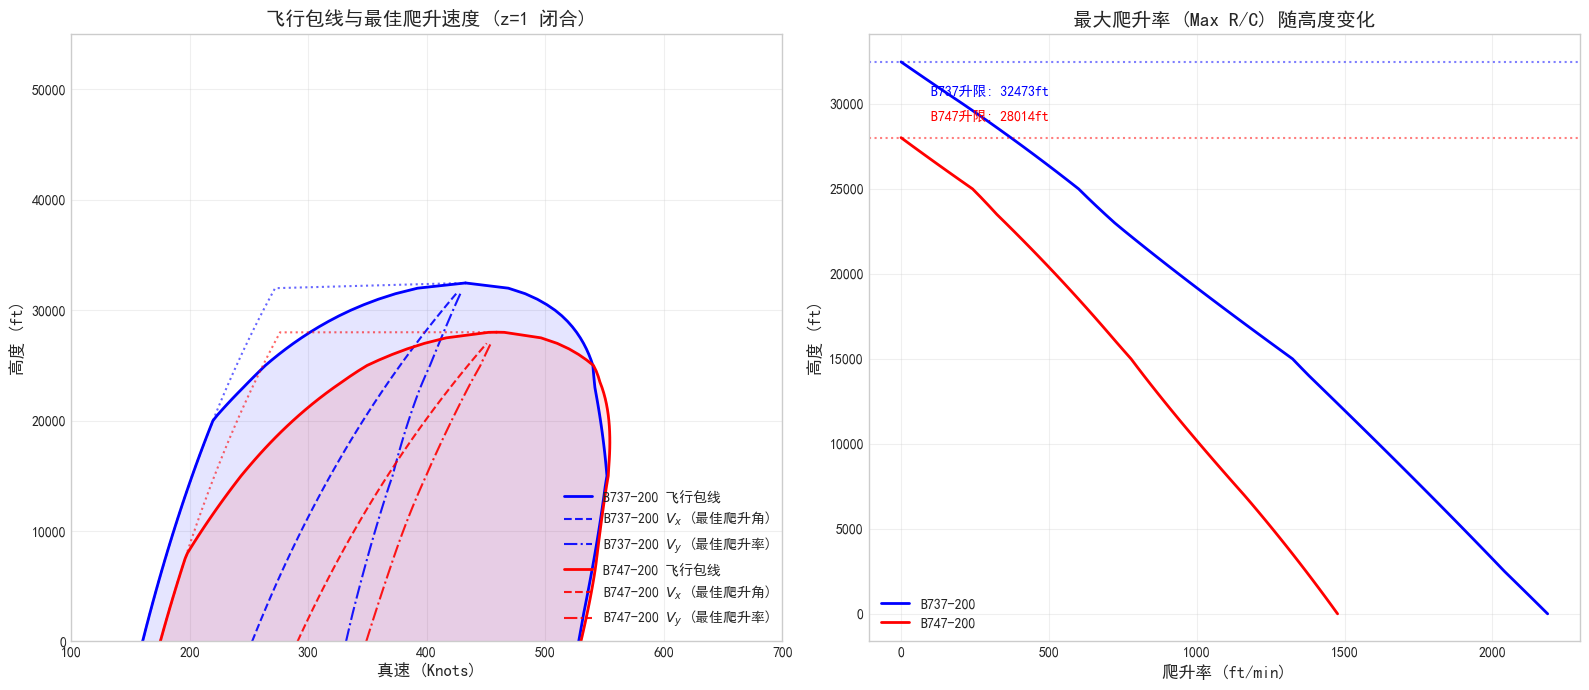


=== 爬升性能关键数据 (海平面) ===


,机型,Vx (kts),最大爬升角,Vy (kts),最大爬升率 (ft/min)
0,B737-200,252.8,4.23°,332.0,2187
1,B747-200,291.1,2.61°,349.1,1476


In [55]:
import matplotlib.pyplot as plt

# === 4. 绘图展示：飞行包线与最佳爬升速度 ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- 函数：绘制单个飞机的包线 ---
def plot_envelope(ax, df, name, color):
    # 1. 绘制包线 (使用 v_min_act 和 v_max 确保闭合)
    ax.plot(df["v_min_act"], df["h"], color=color, linestyle='-', linewidth=2, label=f'{name} 飞行包线')
    ax.plot(df["v_max"], df["h"], color=color, linestyle='-', linewidth=2)
    
    # 2. 绘制失速边界 (虚线参考)
    ax.plot(df["v_stall"], df["h"], color=color, linestyle=':', alpha=0.6)
    
    # 3. 绘制爬升速度线 (Vx, Vy)
    # 过滤掉升限附近的无效数据以美化图像
    mask = (df["max_rc"] > 50) & (df["v_x"].notna())
    ax.plot(df.loc[mask, "v_x"], df.loc[mask, "h"], color=color, linestyle='--', alpha=0.9, linewidth=1.5, label=f'{name} $V_x$ (最佳爬升角)')
    ax.plot(df.loc[mask, "v_y"], df.loc[mask, "h"], color=color, linestyle='-.', alpha=0.9, linewidth=1.5, label=f'{name} $V_y$ (最佳爬升率)')
    
    # 4. 填充包线区域
    ax.fill_betweenx(df["h"], df["v_min_act"], df["v_max"], color=color, alpha=0.1)

# --- 左图：飞行包线 ---
plot_envelope(ax1, df_737, "B737-200", "blue")
plot_envelope(ax1, df_747, "B747-200", "red")

ax1.set_title("飞行包线与最佳爬升速度 (z=1 闭合)", fontsize=14)
ax1.set_xlabel("真速 (Knots)", fontsize=12)
ax1.set_ylabel("高度 (ft)", fontsize=12)
ax1.set_ylim(0, 55000)
ax1.set_xlim(100, 700)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right', fontsize=10)

# --- 右图：最大爬升率 ---
# 过滤无效数据
mask_737 = df_737["max_rc"].notna()
mask_747 = df_747["max_rc"].notna()

ax2.plot(df_737.loc[mask_737, "max_rc"], df_737.loc[mask_737, "h"], 'b-', linewidth=2, label="B737-200")
ax2.plot(df_747.loc[mask_747, "max_rc"], df_747.loc[mask_747, "h"], 'r-', linewidth=2, label="B747-200")

# 标注升限
ceil_737 = df_737.iloc[-1]["h"]
ceil_747 = df_747.iloc[-1]["h"]
ax2.axhline(ceil_737, color='b', linestyle=':', alpha=0.5)
ax2.axhline(ceil_747, color='r', linestyle=':', alpha=0.5)
ax2.text(100, ceil_737 - 2000, f"B737升限: {ceil_737:.0f}ft", color='b')
ax2.text(100, ceil_747 + 1000, f"B747升限: {ceil_747:.0f}ft", color='r')

ax2.set_title("最大爬升率 (Max R/C) 随高度变化", fontsize=14)
ax2.set_xlabel("爬升率 (ft/min)", fontsize=12)
ax2.set_ylabel("高度 (ft)", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# --- 输出海平面性能表 ---
print("\n=== 爬升性能关键数据 (海平面) ===")
res_table = []
for name, df in [("B737-200", df_737), ("B747-200", df_747)]:
    sl = df.iloc[0]
    res_table.append([
        name, 
        f"{sl['v_x']:.1f}", f"{sl['max_angle']:.2f}°",
        f"{sl['v_y']:.1f}", f"{sl['max_rc']:.0f}"
    ])
    
display(pd.DataFrame(res_table, columns=["机型", "Vx (kts)", "最大爬升角", "Vy (kts)", "最大爬升率 (ft/min)"]))

### 5. 巡航性能评估 (Task 4)


[B737-200] 警告: 无法达到 36000 ft，计算将在 32000 ft 进行
[B747-200] 警告: 无法达到 36000 ft，计算将在 28000 ft 进行


,机型,巡航高度,爬升油耗 (lb),爬升时间 (min),巡航初始重量 (lb),最大航程 (等高) (NM),最大航程 (等速) (NM),最大航时 (hr)
0,B737-200,32000 ft,6922,52.4,132077,2368,2510,5.27
1,B747-200,28000 ft,42932,81.4,787067,5668,6276,12.32


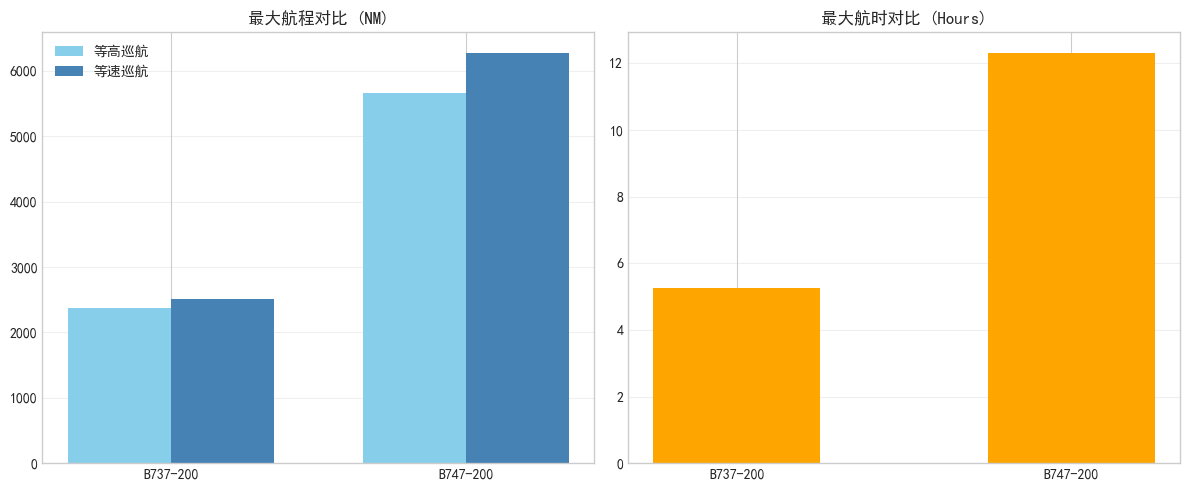

In [56]:
# === 4. 巡航性能评估 (Task 4) - 修正版 ===

def calc_cruise_performance(ac, df_climb, target_alt=36000):
    """
    计算爬升消耗及巡航性能（最大航程-等高/等速、最大航时）
    """
    # --- 1. 计算爬升阶段消耗 (0 -> 36000 ft) ---
    
    # 截取从地面到目标高度的数据
    df_segment = df_climb[df_climb["h"] <= target_alt].copy()
    
    # 【修正 1】: 剔除包含 NaN 的行 (防止积分时出现 NaN)
    df_segment = df_segment.dropna(subset=["max_rc", "v_y"])
    
    # 检查数据是否为空 (比如飞机根本飞不到这个高度)
    if df_segment.empty:
        print(f"[{ac.name}] 无法爬升至 {target_alt} ft (超出包线)")
        return None
        
    # 如果最大高度远小于目标高度，发出警告并更新目标高度
    real_max_h = df_segment["h"].max()
    if real_max_h < target_alt * 0.95:
        print(f"[{ac.name}] 警告: 无法达到 {target_alt} ft，计算将在 {real_max_h:.0f} ft 进行")
        target_alt = real_max_h
    
    # 准备积分变量
    hs = df_segment["h"].values
    rcs = df_segment["max_rc"].values
    v_ys = df_segment["v_y"].values
    
    fuel_burned_climb = 0
    time_climb_min = 0
    
    # 分段积分
    for i in range(len(hs) - 1):
        h_start, h_end = hs[i], hs[i+1]
        dh = h_end - h_start
        
        # 平均爬升率
        rc_avg = (rcs[i] + rcs[i+1]) / 2
        
        # 防止爬升率极小或为0导致除零错误
        if rc_avg < 10: 
            continue # 跳过无法爬升的微小段
        
        dt_min = dh / rc_avg
        time_climb_min += dt_min
        
        # 燃油流量计算
        h_mid = (h_start + h_end) / 2
        v_mid = (v_ys[i] + v_ys[i+1]) / 2
        rho, a = get_atmosphere(h_mid)
        
        # 限制马赫数范围防止插值报错
        m_mid = v_mid / a
        m_mid = np.clip(m_mid, 0.1, 0.9)
        
        thrust = ac.engine.get_thrust(h_mid, m_mid) * ac.n_eng
        sfc = ac.engine.get_sfc(h_mid, m_mid)
        ff_lb_min = (sfc * thrust) / 60
        
        fuel_burned_climb += ff_lb_min * dt_min

    # --- 2. 确定巡航参数 ---
    w_start_cruise = ac.W_to - fuel_burned_climb
    w_end_cruise = ac.W_to - ac.W_fuel
    
    # 再次检查燃油逻辑
    if w_end_cruise >= w_start_cruise:
        print(f"[{ac.name}] 警告: 爬升油耗过大，已无巡航燃油")
        return None

    # 获取巡航高度大气参数
    rho_cr, a_cr_kts = get_atmosphere(target_alt)
    
    # 计算SFC
    Cl_md = np.sqrt(ac.Cd0 / ac.K)
    v_R_cr = np.sqrt((2 * w_start_cruise) / (rho_cr * ac.S * Cl_md)) * 0.592484
    m_cr = np.clip(v_R_cr/a_cr_kts, 0.1, 0.9) # 保护
    sfc_cr = ac.engine.get_sfc(target_alt, m_cr)
    
    # --- 3. 计算最大航程 (等高巡航) ---
    Cl_opt_alt = np.sqrt(ac.Cd0 / (3 * ac.K))
    Cd_opt_alt = ac.Cd0 + ac.K * Cl_opt_alt**2
    
    c_sec = sfc_cr / 3600
    rho_slug = rho_cr
    S_ft = ac.S
    
    term_aero = np.sqrt(Cl_opt_alt) / Cd_opt_alt
    term_dens = np.sqrt(2 / (rho_slug * S_ft))
    term_weight = np.sqrt(w_start_cruise) - np.sqrt(w_end_cruise)
    
    R_const_alt_ft = (2 / c_sec) * term_aero * term_dens * term_weight
    R_const_alt_nm = R_const_alt_ft / 6076.1
    
    # --- 4. 计算最大航程 (等速巡航) ---
    v_R_start_fts = np.sqrt((2 * w_start_cruise) / (rho_cr * ac.S * Cl_md))
    v_R_start_kts = v_R_start_fts * 0.592484
    
    v_cruise_kts = np.sqrt(np.sqrt(3)) * v_R_start_kts
    v_cruise_fts = v_cruise_kts * 1.68781
    
    q = 0.5 * rho_cr * v_cruise_fts**2
    cl_start = w_start_cruise / (q * ac.S)
    cd_start = ac.Cd0 + ac.K * cl_start**2
    E_start = cl_start / cd_start
    
    R_const_spd_ft = (E_start * v_cruise_fts / c_sec) * np.log(w_start_cruise / w_end_cruise)
    R_const_spd_nm = R_const_spd_ft / 6076.1
    
    # --- 5. 计算最大航时 ---
    E_max = 1 / (2 * np.sqrt(ac.Cd0 * ac.K))
    t_endurance_sec = (E_max / c_sec) * np.log(w_start_cruise / w_end_cruise)
    t_endurance_hr = t_endurance_sec / 3600
    
    # 【修正 3】: 定义安全转换函数，处理 potential NaN
    def safe_int(val):
        if pd.isna(val) or np.isinf(val): return 0
        return int(val)

    return {
        "机型": ac.name,
        "巡航高度": f"{target_alt:.0f} ft",
        "爬升油耗 (lb)": safe_int(fuel_burned_climb),
        "爬升时间 (min)": f"{time_climb_min:.1f}",
        "巡航初始重量 (lb)": safe_int(w_start_cruise),
        "最大航程 (等高) (NM)": safe_int(R_const_alt_nm),
        "最大航程 (等速) (NM)": safe_int(R_const_spd_nm),
        "最大航时 (hr)": f"{t_endurance_hr:.2f}"
    }

# 执行计算
if 'df_737' not in locals():
    print("错误: 请先运行 Part 3 生成 df_737 数据!")
else:
    res_737 = calc_cruise_performance(b737, df_737)
    res_747 = calc_cruise_performance(b747, df_747)

    # 过滤掉 None 结果 (防止只有一架飞机计算成功时报错)
    results_list = [res for res in [res_737, res_747] if res is not None]
    
    if results_list:
        df_res = pd.DataFrame(results_list)
        display(df_res)

        # 可视化对比
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # 航程对比
        x = np.arange(len(df_res))
        width = 0.35
        ax1.bar(x - width/2, df_res["最大航程 (等高) (NM)"], width, label='等高巡航', color='skyblue')
        ax1.bar(x + width/2, df_res["最大航程 (等速) (NM)"], width, label='等速巡航', color='steelblue')
        ax1.set_xticks(x)
        ax1.set_xticklabels(df_res["机型"])
        ax1.set_title("最大航程对比 (NM)")
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)

        # 航时对比
        ax2.bar(df_res["机型"], [float(t) for t in df_res["最大航时 (hr)"]], color='orange', width=0.5)
        ax2.set_title("最大航时对比 (Hours)")
        ax2.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("计算失败，没有有效的巡航数据。")

### 6. 起飞与着陆性能评估 (Task 5)

In [57]:
# === 5. 起飞与着陆性能评估 (Task 5) ===

def calc_takeoff_landing(ac):
    """
    计算起飞与着陆性能：
    - 起飞：地面滑跑 (s1) + 空中爬升至35ft (s2)
    - 着陆：空中进近 (s1) + 拉平 (s2) + 地面滑跑 (s3)
    """
    # === 参数准备 ===
    g = 32.174  # 重力加速度 (ft/s^2)
    rho_sl, a_sl_kts = get_atmosphere(0) # 海平面大气
    h_obst = 35 # 障碍高度 (ft)
    
    # 摩擦系数 u
    mu_roll = 0.02  # 起飞滚行 (典型混凝土跑道)
    mu_brake = 0.4  # 着陆刹车 (最大制动)
    
    # 机型特定参数 (Cl_max, W_ld)
    if "737" in ac.name:
        cl_max_to = 1.8
        cl_max_ld = 2.7
        # 典型着陆重量 (取 MTOW 的 85% 作为估算)
        w_ld = ac.W_to * 0.85 
    else: # 747
        cl_max_to = 2.1
        cl_max_ld = 3.0
        w_ld = ac.W_to * 0.85
        
    # ==========================
    # 1. 起飞性能 (Takeoff)
    # ==========================
    
    # --- A. 速度定义 ---
    # 失速速度 (起飞构型)
    v_stall_to_fts = np.sqrt((2 * ac.W_to) / (rho_sl * ac.S * cl_max_to))
    
    # 滑跑速度 v1 = 1.2 * v_stall
    v1_fts = 1.2 * v_stall_to_fts
    v1_kts = v1_fts * 0.592484
    
    # --- B. 力计算 (用于积分公式) ---
    # 初始状态 (v=0): 推力 T - 摩擦 u*W
    thrust_0 = ac.engine.get_thrust(0, 0) * ac.n_eng
    f0 = thrust_0 - mu_roll * ac.W_to
    
    # 离地状态 (v=v1): 净加速力
    # 为了物理严谨性，这里 F1 = Thrust - Drag - Friction
    m_1 = v1_kts / a_sl_kts
    thrust_1 = ac.engine.get_thrust(0, m_1) * ac.n_eng
    
    q_1 = 0.5 * rho_sl * v1_fts**2
    cl_run = 0.8 * cl_max_to # 滑跑离地前姿态
    cd_run = ac.Cd0 + ac.K * cl_run**2
    drag_1 = q_1 * ac.S * cd_run
    lift_1 = q_1 * ac.S * cl_run
    friction_1 = mu_roll * (ac.W_to - lift_1)
    
    f1 = thrust_1 - drag_1 - friction_1
    
    # --- C. 距离计算 ---
    # 1. 地面滑跑 s1
    # s1 = (W/2g) * (v1^2 / (F1-F0)) * ln(F1/F0)
    if f1 <= f0: f1 = f0 + 1 # 防止除零或log负数 (推力异常情况)
    s1_to = (ac.W_to / (2 * g)) * (v1_fts**2 / (f1 - f0)) * np.log(f1 / f0)
    
    # 2. 空中段 s2 (爬升至 35ft)
    # 爬升角 y (sin_gamma) = (T-D)/W
    cl_air = ac.W_to / (q_1 * ac.S) # 离地后 L=W
    cd_air = ac.Cd0 + ac.K * cl_air**2
    drag_air = q_1 * ac.S * cd_air
    
    sin_gamma = (thrust_1 - drag_air) / ac.W_to
    s2_to = h_obst / sin_gamma
    
    total_to_dist = s1_to + s2_to
    
    # ==========================
    # 2. 着陆性能 (Landing)
    # ==========================
    
    # --- A. 速度定义 ---
    # 进近速度 v2 = 1.3 * v_stall (着陆构型)
    v_stall_ld_fts = np.sqrt((2 * w_ld) / (rho_sl * ac.S * cl_max_ld))
    v2_fts = 1.3 * v_stall_ld_fts
    v2_kts = v2_fts * 0.592484
    
    # --- B. 距离计算 ---
    
    # 1. 空中直线段 s1 (35ft -> 拉平起始点)
    # 进近角 y 设定为 3 度 (标准ILS)
    y_app = np.radians(3.0) 
    s1_ld = h_obst / y_app
    
    # 2. 拉平段 s2
    # 用户公式: s2 = v2^2 / (2*g*0.69) * y
    s2_ld = (v2_fts**2 / (2 * g * 0.69)) * y_app
    
    # 3. 地面滑跑 s3
    # 反推力 T_R = 45% 最大推力
    tr = 0.45 * thrust_0 
    
    # 力计算 (减速力 Decelerating Force)
    # F1 (接地瞬间 v=v2): T_R + D
    q_2 = 0.5 * rho_sl * v2_fts**2
    cd_td = ac.Cd0 + ac.K * (w_ld/(q_2*ac.S))**2 # 简算阻力
    drag_td = q_2 * ac.S * cd_td
    
    f1_ld = tr + drag_td # 接地减速力
    
    # F0 (停止瞬间 v=0): T_R + u*W_ld
    f0_ld = tr + mu_brake * w_ld # 停止减速力
    
    # s3 = (W/2g) * (v2^2 / (F1-F0)) * ln(F1/F0)
    # 注意：此处使用 w_ld 作为质量计算基准
    s3_ld = (w_ld / (2 * g)) * (v2_fts**2 / (f1_ld - f0_ld)) * np.log(f1_ld / f0_ld)
    
    total_ld_dist = s1_ld + s2_ld + s3_ld
    
    return {
        "机型": ac.name,
        "起飞重量 (lb)": int(ac.W_to),
        "V1 (离地) (kts)": f"{v1_kts:.1f}",
        "起飞滑跑 (ft)": int(s1_to),
        "起飞总距离 (ft)": int(total_to_dist),
        "着陆重量 (lb)": int(w_ld),
        "Vref (进近) (kts)": f"{v2_kts:.1f}",
        "着陆滑跑 (ft)": int(s3_ld),
        "着陆总距离 (ft)": int(total_ld_dist)
    }

# 执行计算并展示
res_to_ld_737 = calc_takeoff_landing(b737)
res_to_ld_747 = calc_takeoff_landing(b747)

df_to_ld = pd.DataFrame([res_to_ld_737, res_to_ld_747])
print("\n=== 起飞与着陆性能评估 ===")
display(df_to_ld)


=== 起飞与着陆性能评估 ===


,机型,起飞重量 (lb),V1 (离地) (kts),起飞滑跑 (ft),起飞总距离 (ft),着陆重量 (lb),Vref (进近) (kts),着陆滑跑 (ft),着陆总距离 (ft)
0,B737-200,139000,169.7,8515,9030,118150,138.4,2738,3471
1,B747-200,830000,174.8,9594,10558,705500,146.1,3010,3750
